[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HunterBushnell/SCP/blob/main/2_passive.ipynb)

# SCP Step 2 - Passive Properties

Characterize passive membrane behavior for a prepared tune directory, with optional ACT-based parameter proposals when complete targets are selected. The core workflow works locally or in Google Colab without ACT.

Workflow:
- **2.1 Select Tune Directory**: choose a Step 1 tune to tune/check.
- **2.2 Compile and Load Mechanisms**: compile/load configured NEURON `.mod` sources when present.
- **2.3 Build Cell**: instantiate the cell and review section/area summaries.
- **2.4 Passive Targets**: optionally enter target measurements and compute ACT settable properties.
- **2.5 Run Passive Protocol**: run current-injection checks after manual edits.
- **2.6 Plot and Export Trace Check**: review voltage traces and optionally export the diagnostic figure.

This notebook does not directly overwrite model files. It computes values, shows where they should be applied, and leaves final model edits under user control.

Detailed guide: `docs/guides/step_2_passive.md`.

In [1]:
# Environment setup: works locally or in Google Colab
# Autoreload is useful locally, but optional. Some hosted runtimes ship an
# IPython autoreload extension that is not compatible with their Python version.
try:
    ip = get_ipython()
except NameError:
    ip = None
if ip is not None:
    try:
        ip.run_line_magic("load_ext", "autoreload")
        ip.run_line_magic("autoreload", "2")
    except ModuleNotFoundError as exc:
        if getattr(exc, "name", None) == "imp":
            print("IPython autoreload is unavailable in this runtime; continuing without it.")
        else:
            raise
    except Exception as exc:
        print(f"IPython autoreload is unavailable ({exc}); continuing without it.")

import json
import os
import subprocess
import sys
from pathlib import Path

# User-editable only when running in a fresh Colab or unusual local layout.
SCP_REPO_URL = os.environ.get("SCP_REPO_URL", "https://github.com/HunterBushnell/SCP.git")
SCP_REPO_BRANCH = os.environ.get("SCP_REPO_BRANCH", "") or None
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
AUTO_CLONE_REPO = os.environ.get("SCP_AUTO_CLONE", "1" if IN_COLAB else "0") not in {"0", "false", "False"}
INSTALL_DEPS = None  # None = install automatically in Colab, do not install locally.
SCP_REPO_DIR = Path(os.environ.get("SCP_REPO_DIR", "/content/SCP" if IN_COLAB else str(Path.cwd() / "SCP")))


def _looks_like_scp_repo(path: Path) -> bool:
    return (path / "modules").is_dir() and (path / "run_pipeline.py").is_file()


# Minimal pre-import bootstrap. Fresh Colab cannot import SCP helpers until the repo exists.
repo_root = None
env_root = os.environ.get("SCP_ROOT")
if env_root and _looks_like_scp_repo(Path(env_root).expanduser()):
    repo_root = Path(env_root).expanduser().resolve()
else:
    start = Path.cwd().resolve()
    candidates = list((start, *start.parents))
    for base in (start, start.parent):
        try:
            candidates.extend(child for child in base.iterdir() if child.is_dir())
        except Exception:
            pass
    for candidate in candidates:
        if _looks_like_scp_repo(candidate):
            repo_root = candidate.resolve()
            break

if repo_root is None:
    if not AUTO_CLONE_REPO:
        raise FileNotFoundError("Could not find SCP. Set SCP_ROOT or enable SCP_AUTO_CLONE=1.")
    clone_url = SCP_REPO_URL
    token = os.environ.get("SCP_GIT_TOKEN") or os.environ.get("SCP_GITHUB_TOKEN") or os.environ.get("GITHUB_TOKEN")
    if token and clone_url.startswith("https://") and "@" not in clone_url:
        clone_url = clone_url.replace("https://", f"https://{token}@", 1)
    clone_cmd = ["git", "clone", "--depth", "1"]
    if SCP_REPO_BRANCH:
        clone_cmd += ["--branch", SCP_REPO_BRANCH]
    clone_cmd += [clone_url, str(SCP_REPO_DIR)]
    subprocess.check_call(clone_cmd)
    repo_root = SCP_REPO_DIR.resolve()

# Colab can preserve /content/SCP across notebook reloads/restarts. To avoid
# stale code, public notebooks refresh clean ephemeral Colab clones before
# importing SCP modules. Drive-backed clones, forks, branches, and tracked
# local edits are left untouched. Set SCP_AUTO_UPDATE=0 to disable this.
def _scp_repo_slug(url):
    url = str(url).strip()
    if url.endswith(".git"):
        url = url[:-4]
    if "github.com/" in url:
        return url.split("github.com/", 1)[1].lower()
    if url.startswith("git@github.com:"):
        return url.split(":", 1)[1].lower()
    return url.lower()

repo_root_text = str(repo_root)
is_ephemeral_colab_repo = repo_root_text.startswith("/content/") and not repo_root_text.startswith("/content/drive/")
auto_update_repo = os.environ.get("SCP_AUTO_UPDATE", "1") not in {"0", "false", "False"}
if IN_COLAB and auto_update_repo and is_ephemeral_colab_repo and (repo_root / ".git").is_dir():
    branch = SCP_REPO_BRANCH or "main"
    try:
        tracked_changes = subprocess.check_output(
            ["git", "status", "--porcelain", "--untracked-files=no"],
            cwd=str(repo_root),
            text=True,
        ).strip()
        current_branch = subprocess.check_output(
            ["git", "rev-parse", "--abbrev-ref", "HEAD"],
            cwd=str(repo_root),
            text=True,
        ).strip()
        origin_url = subprocess.check_output(
            ["git", "remote", "get-url", "origin"],
            cwd=str(repo_root),
            text=True,
        ).strip()
        if tracked_changes:
            print("SCP repo has tracked local changes; skipping automatic git update.")
        elif _scp_repo_slug(origin_url) != _scp_repo_slug(SCP_REPO_URL):
            print("SCP repo remote differs from SCP_REPO_URL; skipping automatic git update.")
        elif current_branch not in {branch, "HEAD"}:
            print(f"SCP repo is on branch {current_branch!r}; skipping automatic git update.")
        else:
            subprocess.check_call(["git", "fetch", "--depth", "1", "origin", branch], cwd=str(repo_root))
            subprocess.check_call(["git", "reset", "--hard", f"origin/{branch}"], cwd=str(repo_root))
            print(f"SCP repo updated to origin/{branch}.")
    except Exception as exc:
        print(f"Could not auto-update SCP repo ({exc}); continuing with local copy.")

os.environ["SCP_ROOT"] = str(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from modules.notebooks.bootstrap import ensure_notebook_dependencies, is_colab

ensure_notebook_dependencies(install_deps=INSTALL_DEPS)

print("Runtime:", "Colab" if is_colab() else "local")
print("SCP repo:", repo_root)
print("ACT is optional and is resolved only when ACT-based targets/estimates are requested.")


Runtime: local
SCP repo: /home/hrbncv/SCP
ACT is optional and is resolved only when ACT-based targets/estimates are requested.


## 2.1 Select Tune Directory

Choose a tune prepared by Step 1. The bundled examples are `PV/tuned` and `SST/tuned`.

Quick guide:
- `cell_name`: cell folder under `cells/`.
- `tune_name`: tune folder under `cells/<cell>/tunes/`.
- `tunes_parent`: normally `tunes`.
- `tune_dir_override`: optional direct path; overrides `cell_name`/`tune_name` when set.

Use the same tune here that you want to characterize or edit manually after optional ACT proposals are computed.

In [2]:
cell_name = "PV"
tune_name = "tuned"
tunes_parent = "tunes"
tune_dir_override = None  # optional absolute/relative path; overrides cell/tune settings

from modules.tuning import prepare_tuning_notebook_context

context = prepare_tuning_notebook_context(
    cell_name=cell_name,
    tune_name=tune_name,
    tunes_parent=tunes_parent,
    tune_dir_override=tune_dir_override,
    repo_root=repo_root,
    require_compiled_modfiles=False,  # next cell compiles/loads mechanisms when needed
    require_synapse_config=False,
)

tune_dir = context.tune_dir
cell_config = context.cell_config
sim_config = context.sim_config


/home/hrbncv/miniconda3/envs/scp-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport


SCP repo: /home/hrbncv/SCP
Tune dir: /home/hrbncv/SCP/cells/PV/tunes/tuned
Cell: PV | Tune: tuned
Cell loader: allen_manifest
Soma diameter multiplier (Allen adapter): 6.0
Step 1 validation: ok


## 2.2 Compile and Load Mechanisms

Compile the tune's configured `.mod` sources when present and missing compiled output, then load the mechanism library into the current NEURON session. Built-in-only models skip this step.

Quick guide:
- `RECOMPILE_MODFILES = False`: reuse existing compiled mechanisms when possible.
- `RECOMPILE_MODFILES = True`: rebuild from scratch after editing `.mod` files.
- `LOAD_COMPILED_DLL = True`: load mechanisms into this kernel before building the cell when a library exists.

In [3]:
RECOMPILE_MODFILES = False
LOAD_COMPILED_DLL = True
ALLOW_MISSING_MODFILES = True  # built-in-only models need no tune-local MOD sources

from modules.setup.mechanisms import compile_modfiles

mechanism_summary = compile_modfiles(
    tune_dir,
    recompile=RECOMPILE_MODFILES,
    load_dll=LOAD_COMPILED_DLL,
    allow_missing=ALLOW_MISSING_MODFILES,
    cell_config=cell_config,
)
print(json.dumps(mechanism_summary, indent=2))


{
  "status": "ok",
  "modfiles_dir": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles",
  "compiled_dir": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles/x86_64",
  "dll": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles/x86_64/.libs/libnrnmech.so",
  "dll_sha256": "69138685b925aa86239d0b31fcffa0796e1c50c6fbc9bd9fa7290430e7141c5c",
  "compiled_now": false,
  "nrnivmodl": "/home/hrbncv/miniconda3/envs/scp-py311/bin/nrnivmodl",
  "loaded": true,
  "dll_preloaded": false
}


--No graphics will be displayed.


## 2.3 Build Cell

Build the NEURON cell from the selected tune. This normalized cell object is used for current-injection checks and, when selected, the optional ACT passive calculation.

There are no required user options in this cell. Review the printed soma/total area and section summary before choosing the passive area mode in the next step.

In [4]:
from modules.tuning import (
    build_tuning_cell,
    section_summary,
    soma_area_cm2,
    total_area_cm2,
    format_tuning_value,
)

cell = build_tuning_cell(context)
cell_summary = section_summary(cell)
computed_soma_area_cm2 = soma_area_cm2(cell)
computed_total_area_cm2 = total_area_cm2(cell)

print("Cell built successfully.")
print("Soma area (cm²):", format_tuning_value(computed_soma_area_cm2))
print("Total area (cm²):", format_tuning_value(computed_total_area_cm2))
print("Section summary:")
for key, value in cell_summary.items():
    print(f"  {key}: {format_tuning_value(value)}")


na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'PV' from /home/hrbncv/SCP/cells/PV/tunes/tuned/manifest.json, model_type='Biophysical - perisomatic', soma_diam_multiplier=6.0, Vinit=-71.0, loader=standard:Biophysical - perisomatic/allensdk_default
Cell built successfully.
Soma area (cm²): 4.017876017303496e-05
Total area (cm²): 6.182693387308235e-05
Section summary:
  soma: 1
  dend: 41
  apic: 0
  axon: 2
  all_sections: 44
  total_area_um2: 6182.693387308234


## 2.4 Passive Targets

Optionally load target passive measurements from `cell_configs/target_config.json`, notebook overrides, or trace extraction. ACT converts complete targets into settable passive properties only when `COMPUTE_ACT_PASSIVE_PROPOSAL` is explicitly enabled. Computed values are **not applied automatically**.

Target source modes in `target_config.json`:
- `none`: run model characterization without targets or ACT. A missing target config is treated the same way.
- `manual`: use `manual.passive` values directly.
- `traces`: calculate passive values from a user-provided trace file using the `traces.passive` contract.
- `allen_nwb`: calculate passive values from an Allen/ADB `.nwb` file using the `allen_nwb.passive` settings.

Quick guide:
- `TARGET_SOURCE_MODE`: leave `None` to use the configured mode (or targetless mode when the file is absent), or temporarily choose `"none"`, `"manual"`, `"traces"`, or `"allen_nwb"`.
- `USE_TARGET_CONFIG`: read manual passive values from `target_config.json` when source mode is `manual`.
- `manual_passive_targets`: optional notebook override values; leave fields as `None` to use `target_config.json` or extracted targets.
- `EXTRACT_PASSIVE_TARGETS_FROM_NWB`: optional override to force Allen/NWB extraction without changing `target_config.target_source.mode`.
- `TRACE_PASSIVE_PATH` / `NWB_PASSIVE_PATH`: optional path overrides; leave `None` to use `traces.passive.file`, `allen_nwb.file`, or one detected `*_ephys.nwb` in the tune folder.
- `APPLY_EXTRACTED_PASSIVE_TARGETS_TO_CONFIG`: write extracted trace/NWB targets back into `manual.passive` only when explicitly enabled.
- `COMPUTE_ACT_PASSIVE_PROPOSAL`: explicitly enable ACT proposal calculation; it requires complete passive targets from manual values, generic traces, or Allen/NWB extraction.
- `passive_area_mode = "auto"`: soma area for simple cells and total area for detailed cells.
- `passive_area_mode = "soma"`, `"total"`, or `"custom"`: force an area choice.
- `passive_area_scale`: effective-area multiplier for ACT's calculation only; it does not change morphology.
- `custom_passive_area_cm2`: required only when `passive_area_mode = "custom"`.

For ADB/Allen-style tune directories, the values printed below are usually applied manually in the tune's `*_fit.json` file. For generic/custom models, apply the same conceptual values wherever that model defines passive parameters.


In [5]:
TARGET_SOURCE_MODE = None  # None -> configured mode/missing-file targetless mode; or "none", "manual", "traces", "allen_nwb"
USE_TARGET_CONFIG = True
manual_passive_targets = {
    "target_rin_mohm": None,      # input resistance, MΩ
    "target_tau_ms": None,        # membrane time constant, ms
    "target_v_rest_mv": None,     # resting membrane potential, mV
}

# Optional path/mode overrides. Detailed trace/NWB settings live in target_config.json.
EXTRACT_PASSIVE_TARGETS_FROM_NWB = False
APPLY_EXTRACTED_PASSIVE_TARGETS_TO_CONFIG = False
COMPUTE_ACT_PASSIVE_PROPOSAL = False  # explicitly opt in to ACT-derived candidate parameters
TRACE_PASSIVE_PATH = None  # None -> target_config traces.passive.file
NWB_PASSIVE_PATH = None    # None -> target_config allen_nwb.file, or one *_ephys.nwb in tune_dir

passive_area_mode = "auto"   # "auto", "soma", "total", or "custom"
passive_area_scale = 1.0      # effective-area multiplier used only for ACT's estimate
custom_passive_area_cm2 = None

from modules.tuning import compact_display_data, format_tuning_value, resolve_passive_tuning_inputs

passive_resolution = resolve_passive_tuning_inputs(
    context=context,
    cell=cell,
    manual_passive_targets=manual_passive_targets,
    use_target_config=USE_TARGET_CONFIG,
    compute_act_proposal=COMPUTE_ACT_PASSIVE_PROPOSAL,
    target_source_mode=TARGET_SOURCE_MODE,
    trace_path=TRACE_PASSIVE_PATH,
    extract_from_nwb=EXTRACT_PASSIVE_TARGETS_FROM_NWB,
    apply_extracted_targets_to_config=APPLY_EXTRACTED_PASSIVE_TARGETS_TO_CONFIG,
    nwb_path=NWB_PASSIVE_PATH,
    passive_area_mode=passive_area_mode,
    passive_area_scale=passive_area_scale,
    custom_passive_area_cm2=custom_passive_area_cm2,
)

ACTPassiveModule = passive_resolution.act_passive_module
target_config = passive_resolution.target_config
passive_targets = passive_resolution.passive_targets
passive_area = passive_resolution.passive_area
settable_passive_properties = passive_resolution.settable_passive_properties
nwb_passive_summary = passive_resolution.nwb_passive_summary
passive_trace_summary = passive_resolution.passive_trace_summary

print("Target config:", context.cell_configs_dir / "target_config.json")
print("Target source mode:", passive_resolution.target_source_mode)
print("Target source:", target_config.get("target_source", "not configured") if target_config else "not found")
print("Detected NWB files:", [path.name for path in passive_resolution.detected_nwb_files])
print("Generic passive trace path:", passive_resolution.passive_trace_path)
print("NWB passive path:", passive_resolution.nwb_passive_path)
if passive_trace_summary:
    print("Generic trace passive targets extracted:", compact_display_data(passive_trace_summary["targets"]))
if nwb_passive_summary:
    print("NWB passive targets extracted:", compact_display_data(nwb_passive_summary["targets"]))
if (passive_trace_summary or nwb_passive_summary) and APPLY_EXTRACTED_PASSIVE_TARGETS_TO_CONFIG:
    print("Updated target_config.json manual.passive with extracted passive targets.")

print("Passive targets used:")
for key in ("target_rin_mohm", "target_tau_ms", "target_v_rest_mv"):
    print(f"  {key}: {format_tuning_value(passive_targets[key])}")

print("\nPassive area used by ACT:")
for field in (
    "requested_area_mode",
    "selected_area_mode",
    "area_scale",
    "selected_area_cm2",
    "soma_area_cm2",
    "total_area_cm2",
    "section_count",
    "segment_count",
):
    print(f"  {field}: {format_tuning_value(passive_area[field])}")

print("\nSettable passive properties:")
if settable_passive_properties is None:
    print("  not requested (set COMPUTE_ACT_PASSIVE_PROPOSAL=True to use ACT)")
for field in ("e_rev_leak", "g_bar_leak", "Cm"):
    if hasattr(settable_passive_properties, field):
        print(f"  {field}: {format_tuning_value(getattr(settable_passive_properties, field))}")

if passive_resolution.fit_json_candidates:
    print("\nADB/Allen fit JSON candidates to review manually:")
    for candidate in passive_resolution.fit_json_candidates:
        print(f"  {candidate.relative_to(context.repo_root)}")
else:
    print("\nNo *_fit.json file found. For custom models, update the equivalent passive-parameter source manually.")


Target config: /home/hrbncv/SCP/cells/PV/tunes/tuned/cell_configs/target_config.json
Target source mode: manual
Target source: {'mode': 'manual', 'description': 'custom'}
Detected NWB files: []
Generic passive trace path: None
NWB passive path: None
Passive targets used:
  target_rin_mohm: 98.9
  target_tau_ms: 5.9
  target_v_rest_mv: -71.25

Passive area used by ACT:
  requested_area_mode: auto
  selected_area_mode: total
  area_scale: 1.0
  selected_area_cm2: 6.182693387308235e-05
  soma_area_cm2: 4.017876017303496e-05
  total_area_cm2: 6.182693387308235e-05
  section_count: 44
  segment_count: 100

Settable passive properties:
  not requested (set COMPUTE_ACT_PASSIVE_PROPOSAL=True to use ACT)

ADB/Allen fit JSON candidates to review manually:
  cells/PV/tunes/tuned/484635029_fit.json


### Manual Application Guidance

Use the computed ACT values as a manual tuning reference.

For bundled ADB/Allen-style models:
1. Open the tune's `*_fit.json` file printed above.
2. During passive tuning, make sure active conductances are disabled or set according to your passive-tuning convention, while keeping leak/passive terms available.
3. Apply the ACT values to the model's passive fields:
   - `e_rev_leak` → leak reversal potential, commonly `e_pas` or equivalent,
   - `g_bar_leak` → leak conductance, commonly `g_pas` or equivalent,
   - `Cm` → membrane capacitance, commonly section `cm` values.
4. Preserve the model's existing JSON structure and only edit the relevant values/fields.
5. Save the file, restart the kernel, then rerun from the environment setup through **2.3 Build Cell** before checking traces.

For non-ADB/custom models, apply the same values wherever the model defines passive parameters. The notebook intentionally does not auto-edit these files because the correct target fields are model-loader specific.


## 2.5 Run Passive Protocol

Run a small current-injection check. Negative amplitudes are used for passive-property diagnostics. The next cell displays the shared pipeline-style plot and analysis tables. Printed summaries use four significant figures while the stored metrics retain full precision.

Quick guide:
- `sim_params["stim_amp"]`: placeholder nA value overwritten for each entry in `sim_amps`.
- `sim_params["stim_delay"]`: delay before current injection, in ms.
- `sim_params["stim_dur"]`: current-injection duration, in ms.
- `sim_params["h_tstop"]`: total simulation duration, in ms.
- `sim_params["h_dt"]`: integration timestep, in ms.
- `sim_amps`: list of current steps in pA.
- The target comparison table uses `target_config.json` values when present and reports measured-target differences.

After manually editing model parameters, restart the kernel and rerun from the environment setup through **2.3 Build Cell** before rerunning this protocol. The protocol reuses that cell because legacy Allen models cannot be constructed twice in one NEURON process.

In [6]:
sim_params = {
    "stim_amp": -0.1,      # or, overwritten per amplitude below; nA
    "stim_delay": 300,     # ms
    "stim_dur": 1000,      # ms
    "h_tstop": 1500,       # ms
    "h_dt": 0.025,         # ms
    "conditions": dict(sim_config.get("conditions", {}) or {}),
}
sim_amps = [-50, -100]      # pA

from modules.tuning import compare_passive_targets, passive_metric_rows, run_passive_protocol

# Reuse the cell built in 2.3. The protocol reinitializes NEURON for every sweep.
looped_records = run_passive_protocol(
    cell=cell,
    sim_params=sim_params,
    sim_amps=sim_amps,
)
# ACT is optional here; the helper uses an ACT-compatible local measurement when absent.
passive_metrics = passive_metric_rows(
    act_passive_module=ACTPassiveModule,
    looped_records=looped_records,
    sim_params=sim_params,
    sim_amps=sim_amps,
)

passive_target_comparison = compare_passive_targets(passive_metrics, passive_targets)


Passive check metrics:
{
  "amp_pA": -50.0,
  "spike_frequency_hz": 0.0
}
{
  "amp_pA": -100.0,
  "spike_frequency_hz": 0.0
}

Passive target comparison:


,amp_pA,metric,unit,target_value,measured_value,delta,abs_delta,pct_error,status
0,-50.0,v_rest_mV,mV,-71.25,None,None,None,None,missing_value
1,-50.0,rin_MOhm,MOhm,98.90,None,None,None,None,missing_value
2,-50.0,tau_ms,ms,5.90,None,None,None,None,missing_value
3,-100.0,v_rest_mV,mV,-71.25,None,None,None,None,missing_value
4,-100.0,rin_MOhm,MOhm,98.90,None,None,None,None,missing_value
5,-100.0,tau_ms,ms,5.90,None,None,None,None,missing_value


## 2.6 Plot, Analyze, and Export Trace Check

Plot the current-injection voltage traces and display the same grouped analysis used by Step 2 in `0_pipeline.ipynb`. Currents are grouped beneath each target metric and use the trace colors in the table. Spike frequency remains hidden unless a nonzero value triggers a warning. Figure export is optional and writes to `notebook_exports/`, separate from Step 6 analysis and pipeline output data.

Quick guide:
- `PLOT_XLIM` / `PLOT_YLIM`: set axis limits as tuples, or leave `None` for automatic limits.
- `TRACE_COLOR`: voltage trace color when one current is plotted; multiple currents use distinct Matplotlib colors.
- `EXPORT_FIGURE`: set `True` to save the diagnostic figure.
- `EXPORT_FORMATS`: output formats such as `("svg", "png")`.
- `EXPORT_OVERWRITE`: set `True` to replace existing exports at the same path.
- `EXPORT_PATH`: base path for exported figures.

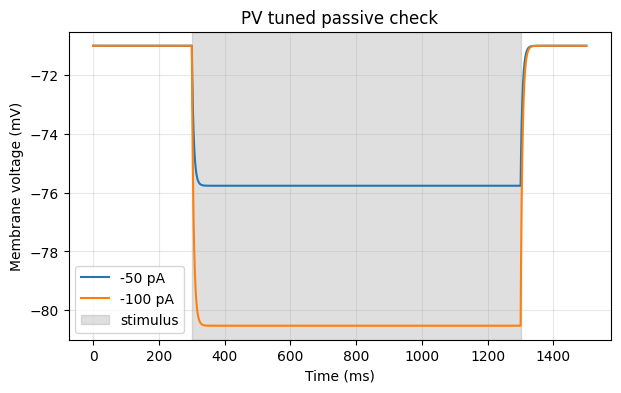

In [11]:
PLOT_XLIM = None          # e.g. (250, 1400)
PLOT_YLIM = None          # e.g. (-100, -40)
TRACE_COLOR = context.cell_config.get("color")  # used only when one current is plotted
EXPORT_FIGURE = False
EXPORT_FORMATS = ("svg", "png")
EXPORT_OVERWRITE = False
EXPORT_PATH = context.tune_dir / "notebook_exports" / "step2_passive_traces"

import matplotlib.pyplot as plt
from modules.analysis.plotting import save_figure_exports
from modules.tuning import display_passive_analysis, passive_amplitude_colors, plot_passive_trace_check

single_trace_color = TRACE_COLOR if len(sim_amps) == 1 else None
passive_amp_colors = passive_amplitude_colors(sim_amps, single_trace_color=single_trace_color)
fig = plot_passive_trace_check(
    looped_records=looped_records,
    sim_params=sim_params,
    sim_amps=sim_amps,
    cell_name=context.cell_name,
    tune_name=context.tune_name,
    xlim=PLOT_XLIM,
    ylim=PLOT_YLIM,
    single_trace_color=single_trace_color,
    amplitude_colors=passive_amp_colors,
)
plt.show()
display_passive_analysis(
    passive_metrics,
    passive_target_comparison,
    amplitude_colors=passive_amp_colors,
)

if EXPORT_FIGURE:
    export_result = save_figure_exports(
        fig,
        export_path=EXPORT_PATH,
        export_formats=EXPORT_FORMATS,
        export_overwrite=EXPORT_OVERWRITE,
    )
else:
    export_result = None


## Next Step

After manually applying the passive values and rerunning the passive check, continue to Step 3 for active-property tuning.
